<a href="https://colab.research.google.com/github/JaimRM/QuantitativeFinance/blob/main/IVCalculator_TheVolatilitySmile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

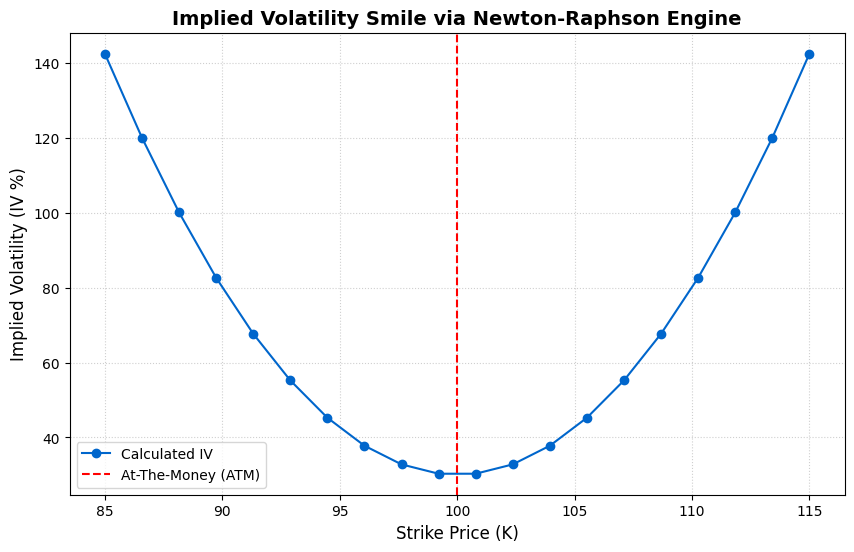

In [2]:
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt

class BlackScholesEngine:
    """
    An institutional-grade Black-Scholes pricing and implied volatility engine.
    """
    def __init__(self, S, r, T, option_type="call"):
        self.S = float(S)          # Underlying Stock Price
        self.r = float(r)          # Risk-free interest rate
        self.T = float(T)          # Time to maturity (in years)
        self.option_type = option_type.lower()

    def price(self, K, sigma):
        """Calculate Black-Scholes theoretical price."""
        if self.T <= 0 or sigma <= 0:
            return max(0.0, self.S - K) if self.option_type == "call" else max(0.0, K - self.S)

        d1 = (np.log(self.S / K) + (self.r + 0.5 * sigma ** 2) * self.T) / (sigma * np.sqrt(self.T))
        d2 = d1 - sigma * np.sqrt(self.T)

        if self.option_type == "call":
            return self.S * si.norm.cdf(d1) - K * np.exp(-self.r * self.T) * si.norm.cdf(d2)
        else:
            return K * np.exp(-self.r * self.T) * si.norm.cdf(-d2) - self.S * si.norm.cdf(-d1)

    def vega(self, K, sigma):
        """Calculate Vega (derivative of price with respect to volatility)."""
        if self.T <= 0 or sigma <= 0:
            return 0.0
        d1 = (np.log(self.S / K) + (self.r + 0.5 * sigma ** 2) * self.T) / (sigma * np.sqrt(self.T))
        return self.S * np.sqrt(self.T) * si.norm.pdf(d1)

    def implied_volatility(self, K, market_price, max_iter=100, tolerance=1e-6):
        """
        Calculate Implied Volatility using the Newton-Raphson numerical method.
        """
        # Intrinsic value floor check
        intrinsic = max(0.0, self.S - K) if self.option_type == "call" else max(0.0, K - self.S)
        if market_price <= intrinsic:
            return 0.0

        # Initial guess (reasonable baseline: 20% to 50%)
        sigma = 0.30

        for _ in range(max_iter):
            bs_price = self.price(K, sigma)
            diff = bs_price - market_price

            if abs(diff) < tolerance:
                return sigma

            v = self.vega(K, sigma)
            if abs(v) < 1e-6:
                break  # Avoid division by zero if vega is too flat

            sigma = sigma - diff / v

            # Bound volatility to realistic numbers to prevent divergence
            if sigma <= 0.0 or sigma > 5.0:
                break

        return np.nan # Return NaN if Newton-Raphson fails to converge

# ==============================================================================
# VISUALIZATION ENVIRONMENT (Simulating Live Market Options Data)
# ==============================================================================
if __name__ == "__main__":
    # Setup fixed parameters
    S_price = 100.0   # Current stock price
    rate = 0.04       # 4% risk-free rate
    expiry = 0.25     # 3 months to maturity

    # Initialize engine
    engine = BlackScholesEngine(S=S_price, r=rate, T=expiry, option_type="call")

    # Range of option strike prices to test
    strikes = np.linspace(85, 115, 20)

    # Simulation of a "Live Market Price" list that exhibits a real-world volatility smile
    simulated_market_ivs = 0.30 + 0.005 * (strikes - S_price)**2  # Creates a U-shaped smile curve
    market_prices = [engine.price(K, sig) for K, sig in zip(strikes, simulated_market_ivs)]

    # Run Newton-Raphson engine to extract the IVs back out of the prices
    calculated_ivs = []
    for K, mp in zip(strikes, market_prices):
        iv = engine.implied_volatility(K, mp)
        calculated_ivs.append(iv * 100) # Convert to percentage

    # Plotting the Volatility Smile
    plt.figure(figsize=(10, 6))
    plt.plot(strikes, calculated_ivs, marker='o', linestyle='-', color='#0066cc', label='Calculated IV')
    plt.axvline(x=S_price, color='red', linestyle='--', label='At-The-Money (ATM)')
    plt.title('Implied Volatility Smile via Newton-Raphson Engine', fontsize=14, fontweight='bold')
    plt.xlabel('Strike Price (K)', fontsize=12)
    plt.ylabel('Implied Volatility (IV %)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()